# Build a supervised model for predicting Koc 

The aim of this assignment is to build a model that can predict the soil sorption coefficient logKoc with a defined applicability domain. It should be able to predict logKoc from a SMILES input and tell the user whether the new molecules fall into its AD. 

#### Tasks:
1) Load the training data
2) Build a supervised model of your choice (e.g., MACCS keys x Random Forest, but feel free to go for something more fancy) on 80% of the training data
3) Use an AD metric of your choice
4) Evaluate model on a 20% test set, and compare the prediction error with your AD metric
5) Predict the Koc and AD for 3 new substances.

In [1]:
# import
from rdkit import Chem
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs


#### 1. Load training data and split into train/test 80/20

In [2]:
# Loading the data from an sdf file
supplier = Chem.SDMolSupplier("KOC_QR.sdf")
df = pd.DataFrame([
    {
        "SMILES": Chem.MolToSmiles(m),
        **{p: m.GetProp(p) for p in ['preferred_name', 'LogKOC']}
    }
    for m in supplier if m is not None
])

In [3]:
df["fingerprint"] = df["SMILES"].apply(lambda x: rdFingerprintGenerator.GetMorganGenerator().GetFingerprint(Chem.MolFromSmiles(x)))

In [4]:
# split data into training and test
X = df["fingerprint"].tolist()
y = df["LogKOC"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 2. Build a supervised model of your choice

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
RFR = RandomForestRegressor(n_estimators=100, random_state=42)
RFR.fit(X_train, y_train)
y_pred = RFR.predict(X_test)

#### 3. Choose an AD metric and define an AD threshold

average log density for training set: -2.7807000792451686
average log density for test set: -2.700568795084904
-3.2004639397213004


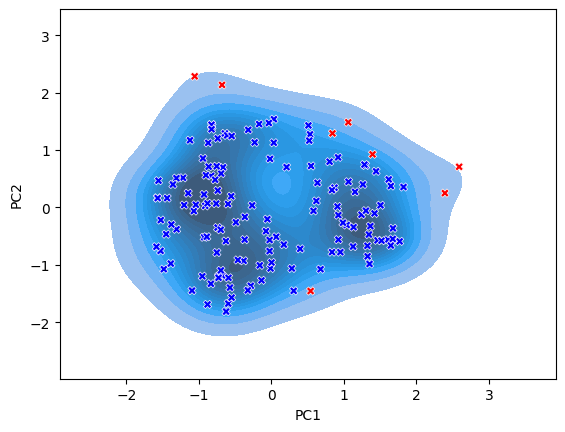

In [6]:
from sklearn.neighbors import KernelDensity
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
kde = KernelDensity(kernel='gaussian', bandwidth=0.5).fit(X_train_pca)
log_density = kde.score_samples(X_test_pca)
print(f"average log density for training set: {kde.score_samples(X_train_pca).mean()}")
print(f"average log density for test set: {log_density.mean()}")

sns.kdeplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], fill=True, levels=15)
threshold = np.percentile(log_density, 5) # set threshold at 10th percentile of the test set kernel densities
test_df = pd.DataFrame(X_test_pca, columns=['PC1', 'PC2'])
test_df['log_density'] = log_density
test_df['within_AD'] = test_df['log_density'] >= threshold
sns.scatterplot(test_df, x='PC1', y='PC2', 
                palette=['red','blue'], hue='within_AD', alpha=1, legend=False, marker='X')
print(threshold)
plt.show()

#### 4) Evaluate model (R2, RMSE) on test set and compare the prediction error with your AD metric

In [7]:
print(f"Training Root Mean Squared Error: {root_mean_squared_error(y_train, RFR.predict(X_train))}")
print(f"Training R^2 Score: {r2_score(y_train, RFR.predict(X_train))}")
print(f"Test Root Mean Squared Error: {root_mean_squared_error(y_test, y_pred)}")
print(f"Test R^2 Score: {r2_score(y_test, y_pred)}")

Training Root Mean Squared Error: 0.31995756903092654
Training R^2 Score: 0.9330029219350564
Test Root Mean Squared Error: 0.6776454300225793
Test R^2 Score: 0.6746176304899634


In [8]:
mask_ad = np.asarray(log_density) > threshold

r2_ad = r2_score(y_test[mask_ad], y_pred[mask_ad])
rmse_ad = np.sqrt(mean_squared_error(y_test[mask_ad], y_pred[mask_ad]))

print("R2 (AD):", r2_ad)
print("RMSE (AD):", rmse_ad)

R2 (AD): 0.6809485212293775
RMSE (AD): 0.6812006122258164


#### 5) Predict the Koc and AD for 3 new substances. 

In [9]:
smiles = {'PFOA': 'C(=O)(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)O', 
          'Bisphenol A': 'CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O',
          'Caffeine': 'CN1C=NC2=C1C(=O)N(C(=O)N2C)C'} # or choose your own! 

In [13]:
gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

fp_list = []

for key in smiles:
    mol = Chem.MolFromSmiles(smiles[key])
    fp = gen.GetFingerprint(mol)
    arr = np.zeros((2048,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    fp_list.append(arr)

for i, key in enumerate(smiles):
    print(f"Predicted LogKOC for {key}: {RFR.predict([fp_list[i]])[0]:.3f}")
    pca_fp = pca.transform([fp_list[i]])
    log_density_fp = kde.score_samples(pca_fp)[0]
    print(f"within AD: {log_density_fp > threshold} (log density: {log_density_fp:.3f})")


Predicted LogKOC for PFOA: 0.691
within AD: True (log density: -2.454)
Predicted LogKOC for Bisphenol A: 2.688
within AD: True (log density: -2.393)
Predicted LogKOC for Caffeine: 2.276
within AD: True (log density: -2.390)


### Questions:
- Which AD metric did you choose, and why?
- I used kernel density because it give a good overview on the domain.
- How well does your model perform? Can you trust your AD metric?
- The performance is alright, the performance gets only slightly better with the AD so I'm not sure if i can trust it, when i make the threshold higher, the performance gets worse, I am not sure why.
- Are the new substances within the AD? Can you trust the Koc predictions? 
- yes they are within, so if the model works like it is supposed to, i would trust it.